In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

In [2]:
from src.dataset import ImageDataset
from torch.utils.data import DataLoader

annotations_file_trainval = Path("../data/preprocessed/trainval/annotations.csv")
img_dir_trainval = Path("../data/preprocessed/trainval/Images")

trainval_dataset = ImageDataset(annotations_file_trainval, img_dir_trainval)
trainval_dl = DataLoader(trainval_dataset, batch_size=8, shuffle=True)

In [3]:
from src.model import Model

model = Model()

In [4]:
from src.configs import (S, C, B, IDX_TO_CLASS, CONFIDENCE_THRESHOLD,
                         NMS_IOU_THRESHOLD)
from src.utils import convert_xywh_coords, IoU
from operator import itemgetter

def decode_preds(preds_batch):
    decoded_preds = []

    for pred in preds_batch:
        pred = pred.reshape((S, S, C + B * 5))
        objects = []

        for i in range(S):
            for j in range(S):
                pred_cell = pred[i][j]

                pred_class_idx = pred_cell[:20].argmax().item()
                pred_class_prob = pred_cell[pred_class_idx].item()
                pred_class = IDX_TO_CLASS[pred_class_idx]

                pred_1_confidence = (pred_cell[24].item() * \
                                     pred_class_prob,)
                pred_2_confidence = (pred_cell[29].item() * \
                                     pred_class_prob,)

                bbox_1 = convert_xywh_coords(pred_cell[20:24], i, j, False)
                bbox_2 = convert_xywh_coords(pred_cell[25:29], i, j, False)

                objects.append((pred_class,) + pred_1_confidence + bbox_1)
                objects.append((pred_class,) + pred_2_confidence + bbox_2)

        decoded_preds.append(objects)

    return decoded_preds

def filter_group_sort_preds(decoded_preds):
    sorted_preds = []

    # 1. filter and group remaining predictions by class
    for image in decoded_preds:
        valid_preds = {}
        for pred in image:
            if pred[1] > CONFIDENCE_THRESHOLD:
                class_name = pred[0]
                if class_name in valid_preds:
                    valid_preds[class_name].append(pred)
                else:
                    valid_preds[class_name] = [pred]

        sorted_preds.append(valid_preds)

    # 2. sort each class's predictions by confidence score
    for image in sorted_preds:
        for class_name in image:
            image[class_name].sort(key=itemgetter(1))

    return sorted_preds


def NMS(preds_batch):
    # 1. decode batch of predictions
    decoded_preds = decode_preds(preds_batch)

    # 2. filter, group, and sort the decoded predictions
    sorted_preds = filter_group_sort_preds(decoded_preds)

    # 3. perform Non-Maximum Suppression
    final_preds = []

    for image in sorted_preds:
        final_img_preds = {}

        for class_name, preds in image.items():
            final_img_preds[class_name] = []

            while preds:
                highest_conf = preds.pop(0)
                final_img_preds[class_name].append(highest_conf)

                preds = [pred for pred in preds if
                         IoU(highest_conf[2:6], pred[2:6]) < NMS_IOU_THRESHOLD]

        final_preds.append(final_img_preds)

    return final_preds

In [27]:
X_batch, y_batch = next(iter(trainval_dl))

preds = model(X_batch)
preds.shape, preds.shape[0]

(torch.Size([8, 1470]), 8)

In [6]:
decoded_preds = decode_preds(preds)
decoded_preds

[[('pottedplant',
   -0.2372863737343458,
   tensor(-7.7508, grad_fn=<SubBackward0>),
   tensor(44.8826, grad_fn=<SubBackward0>),
   tensor(9.4965, grad_fn=<AddBackward0>),
   tensor(-6.1147, grad_fn=<AddBackward0>)),
  ('pottedplant',
   0.17630349245927235,
   tensor(-69.8460, grad_fn=<SubBackward0>),
   tensor(29.0141, grad_fn=<SubBackward0>),
   tensor(52.4491, grad_fn=<AddBackward0>),
   tensor(-26.6019, grad_fn=<AddBackward0>)),
  ('bottle',
   0.13393431881421947,
   tensor(50.4923, grad_fn=<SubBackward0>),
   tensor(-25.4883, grad_fn=<SubBackward0>),
   tensor(22.0733, grad_fn=<AddBackward0>),
   tensor(37.8470, grad_fn=<AddBackward0>)),
  ('bottle',
   0.1964300143234876,
   tensor(87.1353, grad_fn=<SubBackward0>),
   tensor(76.7030, grad_fn=<SubBackward0>),
   tensor(-37.0524, grad_fn=<AddBackward0>),
   tensor(-66.2915, grad_fn=<AddBackward0>)),
  ('diningtable',
   -0.12233827583961521,
   tensor(111.0291, grad_fn=<SubBackward0>),
   tensor(20.1567, grad_fn=<SubBackward0>),

In [7]:
sorted_preds = filter_group_sort_preds(decoded_preds)
sorted_preds

[{'pottedplant': [('pottedplant',
    0.17630349245927235,
    tensor(-69.8460, grad_fn=<SubBackward0>),
    tensor(29.0141, grad_fn=<SubBackward0>),
    tensor(52.4491, grad_fn=<AddBackward0>),
    tensor(-26.6019, grad_fn=<AddBackward0>))],
  'bottle': [('bottle',
    0.13393431881421947,
    tensor(50.4923, grad_fn=<SubBackward0>),
    tensor(-25.4883, grad_fn=<SubBackward0>),
    tensor(22.0733, grad_fn=<AddBackward0>),
    tensor(37.8470, grad_fn=<AddBackward0>)),
   ('bottle',
    0.16508852370401428,
    tensor(117.1946, grad_fn=<SubBackward0>),
    tensor(16.9852, grad_fn=<SubBackward0>),
    tensor(4.2010, grad_fn=<AddBackward0>),
    tensor(80.5036, grad_fn=<AddBackward0>)),
   ('bottle',
    0.19381181182851215,
    tensor(30.9823, grad_fn=<SubBackward0>),
    tensor(140.5552, grad_fn=<SubBackward0>),
    tensor(42.3281, grad_fn=<AddBackward0>),
    tensor(58.4520, grad_fn=<AddBackward0>)),
   ('bottle',
    0.1964300143234876,
    tensor(87.1353, grad_fn=<SubBackward0>),
  

In [8]:
import torch 
nums = torch.arange(10)
nums = nums.sort()[0]

print(nums)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [9]:
nums = [num for num in nums if num == 2 or num == 4 or num == 6]
nums

[tensor(2), tensor(4), tensor(6)]

In [10]:
final_preds = []

for image in sorted_preds:
    final_img_preds = {}

    for class_name, preds in image.items():
        final_img_preds[class_name] = []

        while preds:
            highest_conf = preds.pop(0)
            final_img_preds[class_name].append(highest_conf)

            preds = [pred for pred in preds if
                     IoU(highest_conf[2:6], pred[2:6]) < NMS_IOU_THRESHOLD]

    final_preds.append(final_img_preds)

In [11]:
final_preds, len(final_preds)

([{'pottedplant': [('pottedplant',
     0.17630349245927235,
     tensor(-69.8460, grad_fn=<SubBackward0>),
     tensor(29.0141, grad_fn=<SubBackward0>),
     tensor(52.4491, grad_fn=<AddBackward0>),
     tensor(-26.6019, grad_fn=<AddBackward0>))],
   'bottle': [('bottle',
     0.13393431881421947,
     tensor(50.4923, grad_fn=<SubBackward0>),
     tensor(-25.4883, grad_fn=<SubBackward0>),
     tensor(22.0733, grad_fn=<AddBackward0>),
     tensor(37.8470, grad_fn=<AddBackward0>)),
    ('bottle',
     0.16508852370401428,
     tensor(117.1946, grad_fn=<SubBackward0>),
     tensor(16.9852, grad_fn=<SubBackward0>),
     tensor(4.2010, grad_fn=<AddBackward0>),
     tensor(80.5036, grad_fn=<AddBackward0>)),
    ('bottle',
     0.19381181182851215,
     tensor(30.9823, grad_fn=<SubBackward0>),
     tensor(140.5552, grad_fn=<SubBackward0>),
     tensor(42.3281, grad_fn=<AddBackward0>),
     tensor(58.4520, grad_fn=<AddBackward0>)),
    ('bottle',
     0.1964300143234876,
     tensor(87.1353, 

In [12]:
y_batch.shape, y_batch, y_batch[0].shape

(torch.Size([8, 7, 7, 30]),
 tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.000

In [13]:
(y_batch[0].flatten(0, 1))[29]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.])

In [14]:
from src.configs import IDX_TO_CLASS

def find_objects(y_batch, device):
    y_batch = y_batch.flatten(1, 2)
    truth_objects = []

    for target in y_batch:
        class_objects = {}
        
        for cell in target:
            class_name = IDX_TO_CLASS[int(torch.argmax(cell[:C]))]

            if cell[C+4] == 1:
                # the additional 0 is to classify that specific object as 
                # unmatched with a prediction. 1 is for matched. 
                bboxes = torch.cat((cell[C:C+4], torch.tensor([0]).to(device)))
                if class_name in class_objects:
                    class_objects[class_name].append(bboxes)
                else:
                    class_objects[class_name] = [bboxes]

        truth_objects.append(class_objects)
        
    return truth_objects

truth_objects = find_objects(y_batch, "cpu")

In [15]:
len(truth_objects)

8

In [16]:
final_preds[0]

{'pottedplant': [('pottedplant',
   0.17630349245927235,
   tensor(-69.8460, grad_fn=<SubBackward0>),
   tensor(29.0141, grad_fn=<SubBackward0>),
   tensor(52.4491, grad_fn=<AddBackward0>),
   tensor(-26.6019, grad_fn=<AddBackward0>))],
 'bottle': [('bottle',
   0.13393431881421947,
   tensor(50.4923, grad_fn=<SubBackward0>),
   tensor(-25.4883, grad_fn=<SubBackward0>),
   tensor(22.0733, grad_fn=<AddBackward0>),
   tensor(37.8470, grad_fn=<AddBackward0>)),
  ('bottle',
   0.16508852370401428,
   tensor(117.1946, grad_fn=<SubBackward0>),
   tensor(16.9852, grad_fn=<SubBackward0>),
   tensor(4.2010, grad_fn=<AddBackward0>),
   tensor(80.5036, grad_fn=<AddBackward0>)),
  ('bottle',
   0.19381181182851215,
   tensor(30.9823, grad_fn=<SubBackward0>),
   tensor(140.5552, grad_fn=<SubBackward0>),
   tensor(42.3281, grad_fn=<AddBackward0>),
   tensor(58.4520, grad_fn=<AddBackward0>)),
  ('bottle',
   0.1964300143234876,
   tensor(87.1353, grad_fn=<SubBackward0>),
   tensor(76.7030, grad_fn=<S

In [17]:
truth_objects

[{'train': [tensor([0.5938, 0.7500, 0.8973, 0.3571, 0.0000])]},
 {'person': [tensor([0.6250, 0.6562, 0.1964, 0.4688, 0.0000])],
  'horse': [tensor([0.3438, 0.8438, 0.7054, 0.5848, 0.0000])]},
 {'person': [tensor([0.0938, 0.8750, 0.4375, 0.6920, 0.0000]),
   tensor([0.2812, 0.2500, 0.4911, 0.7812, 0.0000])]},
 {'bird': [tensor([0.4375, 0.5312, 0.4554, 0.7054, 0.0000])]},
 {'dog': [tensor([0.7188, 0.2188, 0.2634, 0.2768, 0.0000])]},
 {'aeroplane': [tensor([0.5312, 0.9062, 0.9911, 0.7143, 0.0000]),
   tensor([0.9688, 0.2500, 0.3080, 0.1964, 0.0000])]},
 {'train': [tensor([0.1250, 0.4688, 0.3170, 0.5446, 0.0000]),
   tensor([0.6250, 0.3125, 0.2500, 0.4196, 0.0000]),
   tensor([0.0312, 0.0938, 0.2723, 0.5000, 0.0000])],
  'person': [tensor([0.2188, 0.5312, 0.0536, 0.1920, 0.0000]),
   tensor([0.8438, 0.6875, 0.2411, 0.3750, 0.0000])]},
 {'person': [tensor([0.8438, 0.7812, 0.1295, 0.4777, 0.0000])],
  'horse': [tensor([0.1562, 0.1562, 0.5179, 0.5982, 0.0000])]}]

In [18]:
truth_objects[0]

{'train': [tensor([0.5938, 0.7500, 0.8973, 0.3571, 0.0000])]}

In [19]:
TP_IOU_THRESHOLD = 0.5

def tp_fp_and_count_objects(final_preds, truth_objects, all_tp_fp_by_class, class_object_totals):
    # 1. iterate through each image prediction/label in the batch
    for b in range(len(final_preds)):
        img_preds = final_preds[b]
        objects = truth_objects[b]

        # 2. iterate through each class
        for class_name, preds in img_preds.items():            
            # a. if any of the ground truth objects belong to the class
            if class_name in objects:
                # iterate through each prediction, find max IoU truth object, and
                # if the max IoU surpasses the threshold, it is a TP, else FP
                for pred in preds:
                    IoUs = [IoU(object_[0:4], pred[2:6]) for object_ in objects[class_name]]
                    max_idx = IoUs.index(max(IoUs))
                    
                    if IoUs[max_idx] < TP_IOU_THRESHOLD:
                        all_tp_fp_by_class[class_name].append((pred[1], False))
                        
                    elif objects[class_name][max_idx][-1] == 0:
                        all_tp_fp_by_class[class_name].append((pred[1], True))
                        objects[class_name][max_idx][-1] = 1
                        
                    else:
                        all_tp_fp_by_class[class_name].append((pred[1], False))
            else:
                # b. all predictions belonging to class are FP since there are
                # no ground truth objects belonging to that class
                for pred in preds:
                    all_tp_fp_by_class[class_name].append((pred[1], False))    

        # 3. add the number of objects that belong to each class to the total
        for class_name, object_list in objects.items():
            class_object_totals[class_name] += len(object_list)

In [20]:
all_tp_fp_by_class = {
    "aeroplane": [],
    "bicycle": [],
    "bird": [],
    "boat": [],
    "bottle": [],
    "bus": [],
    "car": [],
    "cat": [],
    "chair": [],
    "cow":[],
    "diningtable": [],
    "dog": [],
    "horse": [],
    "motorbike": [],
    "person": [],
    "pottedplant": [],
    "sheep": [],
    "sofa": [],
    "train": [],
    "tvmonitor": [],
}

precision_recall_lists = {
    "aeroplane": ([], []),
    "bicycle": ([], []),
    "bird": ([], []),
    "boat": ([], []),
    "bottle": ([], []),
    "bus": ([], []),
    "car": ([], []),
    "cat": ([], []),
    "chair": ([], []),
    "cow":([], []),
    "diningtable": ([], []),
    "dog": ([], []),
    "horse": ([], []),
    "motorbike": ([], []),
    "person": ([], []),
    "pottedplant": ([], []),
    "sheep": ([], []),
    "sofa": ([], []),
    "train": ([], []),
    "tvmonitor": ([], []),
}

class_object_totals = {
    "aeroplane": 0,
    "bicycle": 0,
    "bird": 0,
    "boat": 0,
    "bottle": 0,
    "bus": 0,
    "car": 0,
    "cat": 0,
    "chair": 0,
    "cow":0,
    "diningtable": 0,
    "dog": 0,
    "horse": 0,
    "motorbike": 0,
    "person": 0,
    "pottedplant": 0,
    "sheep": 0,
    "sofa": 0,
    "train": 0,
    "tvmonitor": 0,
}

In [21]:
tp_fp_and_count_objects(final_preds, truth_objects, all_tp_fp_by_class, class_object_totals)

all_tp_fp_by_class["bird"].sort(key=itemgetter(0), reverse=True)
all_tp_fp_by_class, class_object_totals

({'aeroplane': [(0.2463791184629187, False),
   (0.31016657708643436, False),
   (0.09473806654799866, False),
   (0.0675539919619812, False),
   (0.062056217260987534, False),
   (0.06788324902916543, False),
   (0.09805553468896111, False),
   (0.14273739934901997, False),
   (0.18640326545669872, False),
   (0.19798889203296532, False),
   (0.21163437902283988, False),
   (0.2808945901438733, False),
   (0.1455704401853346, False),
   (0.06000005228553151, False)],
  'bicycle': [(0.13161575280186888, False),
   (0.2269314659522248, False),
   (0.45415531062450043, False),
   (0.0679746343235621, False),
   (0.15569388349695412, False),
   (0.1127008089867445, False),
   (0.1258680006775421, False),
   (0.13317454022933362, False),
   (0.25878706507569227, False),
   (0.19372341152296357, False),
   (0.06200575650425666, False),
   (0.08433216209603245, False),
   (0.13854936329665613, False),
   (0.0687944521144459, False),
   (0.14235716578355362, False),
   (0.1549839958362753, Fa

In [22]:
def mean_average_precision(all_tp_fp_by_class, class_object_totals, precision_recall_lists):
    ap_by_class = {}
    
    for class_name, tp_fp_list in all_tp_fp_by_class.items():
        if class_object_totals[class_name] == 0:
            continue 
            
        AP = 0
        
        # 1. sort every list of TP/FPs in each class
        tp_fp_list.sort(key=itemgetter(0), reverse=True)

        # 2. iterate through list of TP/FPs and compute precision/recall
        true_positives = 0
        
        precision_denom = 0 # denominator - <total TP or FP>
        recall_denom = class_object_totals[class_name] # denominator - <total objects in class>
        
        previous_recall = 0

        precision_list = precision_recall_lists[class_name][0]
        recall_list = precision_recall_lists[class_name][1]

        for _, status in tp_fp_list:
            true_positives += status
            precision_denom += 1
            
            precision = true_positives / precision_denom
            recall = true_positives / recall_denom

            precision_list.append(precision)
            recall_list.append(recall)

            delta_recall = recall - previous_recall
            AP += precision * delta_recall

            previous_recall = recall

        ap_by_class[class_name] = AP

    mAP = sum(ap_by_class.values()) / len(ap_by_class)

    return mAP, ap_by_class

In [23]:
mAP, ap_by_class =  mean_average_precision(all_tp_fp_by_class, class_object_totals, precision_recall_lists)
mAP, ap_by_class

(0.0,
 {'aeroplane': 0.0,
  'bird': 0.0,
  'dog': 0.0,
  'horse': 0.0,
  'person': 0.0,
  'train': 0.0})

In [24]:
precision_recall_lists

{'aeroplane': ([0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]),
 'bicycle': ([], []),
 'bird': ([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]),
 'boat': ([], []),
 'bottle': ([], []),
 'bus': ([], []),
 'car': ([], []),
 'cat': ([], []),
 'chair': ([], []),
 'cow': ([], []),
 'diningtable': ([], []),
 'dog': ([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]),
 'horse': ([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]),
 'motorbike': ([], []),
 'person': ([0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]),
 'pottedplant': ([], []),
 'sheep': ([], []),


In [25]:
len(precision_recall_lists)

20

<Axes: >

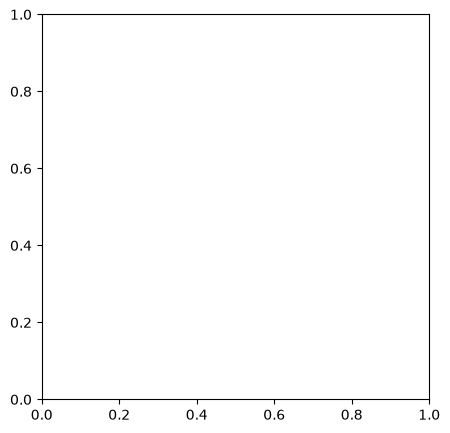

In [26]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1, figsize=(5, 5))

ax